# Workshop - Machine Gnostics

# 01. Setup & Dependencies

In this workshop, we'll compare **Scikit-Learn** and **Machine Gnostics** for polynomial regression tasks. 

## Required Python Libraries
- **Scikit-Learn** - Industry-standard Machine Learning library
- **Machine Gnostics** - Alternative ML library with mathematical insights
- **NumPy** - Numerical computing library
- **Matplotlib** - Data visualization library

## Installation Instructions
Uncomment the lines below to install required packages (recommended: use a virtual environment)

In [40]:
# Uncomment below to install packages (recommended for first run)
# !pip install scikit-learn
# !pip install machinegnostics
# !pip install numpy matplotlib

# Import all required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from machinegnostics.models import PolynomialRegressor

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


# 02. Generate Sample Data

We'll create synthetic data with an exponential trend and intentionally add **outliers** to test how each model handles noisy data.

**Key Question:** How robust are these models to outliers?

In [41]:
# Generate synthetic data with exponential pattern
np.random.seed(42)

# Create 10 data points
X = np.linspace(0, 2, 10).reshape(-1, 1)

# Generate y values with exponential trend: y = 2.0 * e^(1.8*x) + noise
# Base formula: e^(1.8*x) creates exponential growth
# Noise: small random variation (N(0, 0.2)) to simulate real-world data
y = 2.0 * np.exp(1.8 * X.ravel()) + np.random.normal(0, 0.2, 10)

# Add outliers: artificially introduce 2 extreme values
# These represent measurement errors or unusual observations
index_outliers = [2, 7]
outlier_values = [25, 10]
y[index_outliers] = outlier_values

print("Dataset created successfully!")
print(f"- Number of samples: {len(X)}")
print(f"- Outliers at indices: {index_outliers}")
print(f"- Outlier values: {outlier_values}")

Dataset created successfully!
- Number of samples: 10
- Outliers at indices: [2, 7]
- Outlier values: [25, 10]


In [42]:
# Display the data
print("=" * 50)
print("TRAINING DATA")
print("=" * 50)
print("\nX values:")
print(X.flatten())
print("\nY values:")
print(y)
print("\nData Summary:")
print(f"  Min Y: {y.min():.2f}")
print(f"  Max Y: {y.max():.2f}")
print(f"  Mean Y: {y.mean():.2f}")
print(f"  Std Dev: {y.std():.2f}")
print("=" * 50)

TRAINING DATA

X values:
[0.         0.22222222 0.44444444 0.66666667 0.88888889 1.11111111
 1.33333333 1.55555556 1.77777778 2.        ]

Y values:
[ 2.09934283  2.95599654 25.          6.94483982  9.85923417 14.73128481
 22.36219532 10.         48.97116552 73.3049809 ]

Data Summary:
  Min Y: 2.10
  Max Y: 73.30
  Mean Y: 21.62
  Std Dev: 21.67


# 03. Model Training & Comparison

We'll train both models on the same dataset and compare their performance metrics.

**Degree of Polynomial:** We'll use degree 3, meaning: $\hat{y} = a_0 + a_1x + a_2x^2 + a_3x^3$

## Step 1: Train Scikit-Learn Model

Scikit-Learn is the industry standard. We'll use `PolynomialFeatures` + `LinearRegression`.

In [43]:
# SCIKIT-LEARN MODEL
print("\n" + "="*60)
print("SCIKIT-LEARN: Polynomial Regression (Degree 3)")
print("="*60)

# Set polynomial degree
degree = 3

# Step 1: Transform features to polynomial features
# This converts X into [1, X, X^2, X^3]
poly = PolynomialFeatures(degree=degree)
X_poly = poly.fit_transform(X)
print(f"\nPolynomial features shape: {X_poly.shape}")
print("Features: [1, X, X², X³]")

# Step 2: Fit the linear model on polynomial features
model_sk = LinearRegression()
model_sk.fit(X_poly, y)

# Step 3: Make predictions
y_pred_sk = model_sk.predict(X_poly)

# Step 4: Calculate performance metrics
mse_sk = mean_squared_error(y, y_pred_sk)
mae_sk = mean_absolute_error(y, y_pred_sk)

print(f"\nTraining Results:")
print(f"  Mean Squared Error (MSE): {mse_sk:.4f}")
print(f"  Mean Absolute Error (MAE): {mae_sk:.4f}")
print(f"  Root MSE (RMSE): {np.sqrt(mse_sk):.4f}")
print(f"\nModel Coefficients:")
print(f"  Intercept: {model_sk.intercept_:.4f}")
print(f"  Coefficients: {model_sk.coef_}")
print("="*60)


SCIKIT-LEARN: Polynomial Regression (Degree 3)

Polynomial features shape: (10, 4)
Features: [1, X, X², X³]

Training Results:
  Mean Squared Error (MSE): 53.8968
  Mean Absolute Error (MAE): 6.2008
  Root MSE (RMSE): 7.3414

Model Coefficients:
  Intercept: -0.1914
  Coefficients: [  0.          68.31455008 -98.30120666  41.33233527]


In [44]:
# Optional: View PolynomialFeatures documentation
# Uncomment below to see detailed information
# help(PolynomialFeatures)

## Step 2: Train Machine Gnostics Model

Machine Gnostics is designed to handle polynomial regression more directly, with potential advantages in numerical stability.

In [45]:
# MACHINE GNOSTICS MODEL
print("\n" + "="*60)
print("MACHINE GNOSTICS: Polynomial Regressor (Degree 3)")
print("="*60)

# Create and train the model
# Machine Gnostics handles polynomial features internally
model_mg = PolynomialRegressor(degree=degree)
model_mg.fit(X, y)

# Make predictions
y_pred_mg = model_mg.predict(X)

# Calculate performance metrics
mse_mg = mean_squared_error(y, y_pred_mg)
mae_mg = mean_absolute_error(y, y_pred_mg)

print(f"\nTraining Results:")
print(f"  Mean Squared Error (MSE): {mse_mg:.4f}")
print(f"  Mean Absolute Error (MAE): {mae_mg:.4f}")
print(f"  Root MSE (RMSE): {np.sqrt(mse_mg):.4f}")
print("="*60)


MACHINE GNOSTICS: Polynomial Regressor (Degree 3)

Training Results:
  Mean Squared Error (MSE): 90.6413
  Mean Absolute Error (MAE): 4.7092
  Root MSE (RMSE): 9.5206


In [23]:
# Optional: View PolynomialRegressor documentation
# Uncomment below to see detailed information
# help(PolynomialRegressor)

# 04. Model Comparison & Analysis

In [24]:
# PERFORMANCE COMPARISON
print("\n" + "="*60)
print("COMPARISON: Scikit-Learn vs Machine Gnostics")
print("="*60)
print("\n{:<25} {:<20} {:<20}".format("Metric", "Scikit-Learn", "Machine Gnostics"))
print("-"*65)
print("{:<25} {:<20.4f} {:<20.4f}".format("MSE", mse_sk, mse_mg))
print("{:<25} {:<20.4f} {:<20.4f}".format("MAE", mae_sk, mae_mg))
print("{:<25} {:<20.4f} {:<20.4f}".format("RMSE", np.sqrt(mse_sk), np.sqrt(mse_mg)))
print("-"*65)



COMPARISON: Scikit-Learn vs Machine Gnostics

Metric                    Scikit-Learn         Machine Gnostics    
-----------------------------------------------------------------
MSE                       53.8968              90.6413             
MAE                       6.2008               4.7092              
RMSE                      7.3414               9.5206              
-----------------------------------------------------------------


# 05. Visualization & Observations

Let's visualize how both models fit the data and compare their predictions.

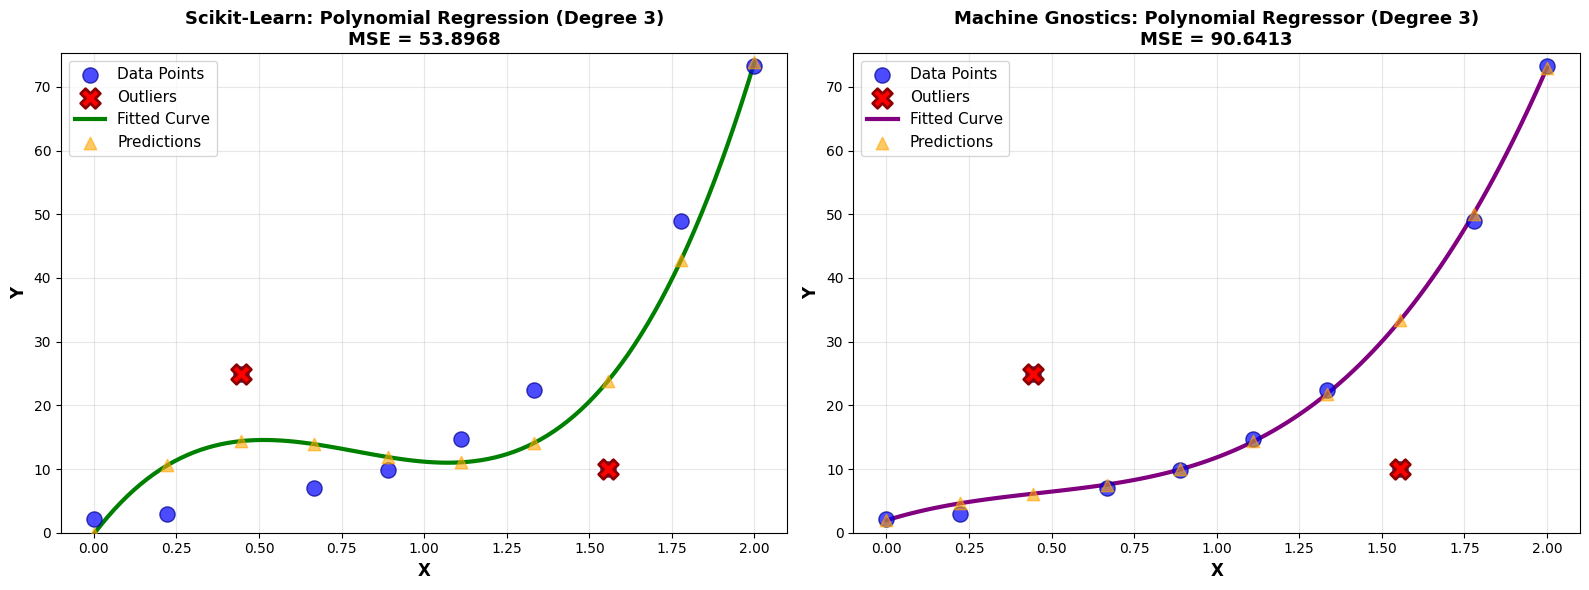

✓ Visualization complete! Compare the two fitted curves above.


In [25]:
# Create smooth curve for visualization
X_smooth = np.linspace(0, 2, 100).reshape(-1, 1)
X_smooth_poly = poly.transform(X_smooth)

# Get predictions from both models
y_smooth_sk = model_sk.predict(X_smooth_poly)
y_smooth_mg = model_mg.predict(X_smooth)  # Machine Gnostics handles polynomial expansion internally

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ===== LEFT PLOT: Scikit-Learn =====
ax = axes[0]
# Plot original data
ax.scatter(X, y, color='blue', s=120, label='Data Points', zorder=3, alpha=0.7, edgecolors='darkblue')
# Highlight outliers
ax.scatter(X[index_outliers], y[index_outliers], color='red', s=200, label='Outliers', 
           zorder=4, marker='X', edgecolors='darkred', linewidths=2)
# Plot fitted curve
ax.plot(X_smooth, y_smooth_sk, 'g-', linewidth=3, label='Fitted Curve', zorder=2)
# Plot predictions on training data
ax.scatter(X, y_pred_sk, color='orange', s=80, label='Predictions', marker='^', zorder=3, alpha=0.6)

ax.set_xlabel('X', fontsize=12, fontweight='bold')
ax.set_ylabel('Y', fontsize=12, fontweight='bold')
ax.set_title(f'Scikit-Learn: Polynomial Regression (Degree {degree})\nMSE = {mse_sk:.4f}', 
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, max(y) + 2])

# ===== RIGHT PLOT: Machine Gnostics =====
ax = axes[1]
# Plot original data
ax.scatter(X, y, color='blue', s=120, label='Data Points', zorder=3, alpha=0.7, edgecolors='darkblue')
# Highlight outliers
ax.scatter(X[index_outliers], y[index_outliers], color='red', s=200, label='Outliers', 
           zorder=4, marker='X', edgecolors='darkred', linewidths=2)
# Plot fitted curve
ax.plot(X_smooth, y_smooth_mg, 'purple', linewidth=3, label='Fitted Curve', zorder=2)
# Plot predictions on training data
ax.scatter(X, y_pred_mg, color='orange', s=80, label='Predictions', marker='^', zorder=3, alpha=0.6)

ax.set_xlabel('X', fontsize=12, fontweight='bold')
ax.set_ylabel('Y', fontsize=12, fontweight='bold')
ax.set_title(f'Machine Gnostics: Polynomial Regressor (Degree {degree})\nMSE = {mse_mg:.4f}', 
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, max(y) + 2])

plt.tight_layout()
plt.show()

print("✓ Visualization complete! Compare the two fitted curves above.")


RESIDUALS ANALYSIS: How far off are predictions?

Scikit-Learn Residuals:
  Mean: 0.0000
  Std Dev: 7.3414
  Max Absolute Error: 13.7884

Machine Gnostics Residuals:
  Mean: -0.6528
  Std Dev: 9.4982
  Max Absolute Error: 23.3540


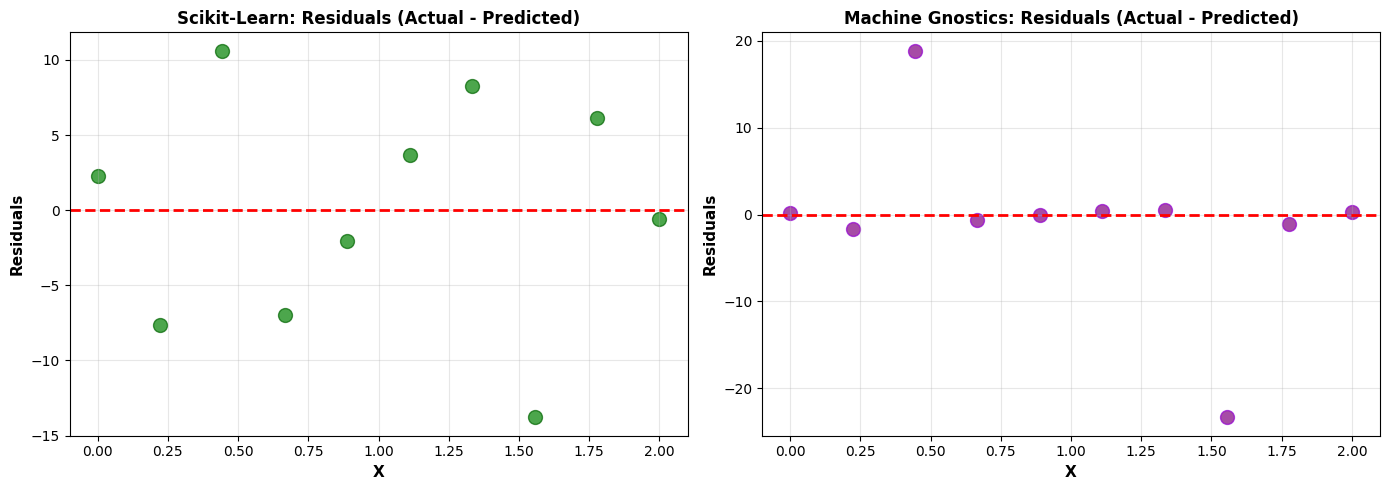

In [26]:
# RESIDUALS ANALYSIS
print("\n" + "="*60)
print("RESIDUALS ANALYSIS: How far off are predictions?")
print("="*60)

residuals_sk = y - y_pred_sk
residuals_mg = y - y_pred_mg

print("\nScikit-Learn Residuals:")
print(f"  Mean: {residuals_sk.mean():.4f}")
print(f"  Std Dev: {residuals_sk.std():.4f}")
print(f"  Max Absolute Error: {np.abs(residuals_sk).max():.4f}")

print("\nMachine Gnostics Residuals:")
print(f"  Mean: {residuals_mg.mean():.4f}")
print(f"  Std Dev: {residuals_mg.std():.4f}")
print(f"  Max Absolute Error: {np.abs(residuals_mg).max():.4f}")

# Residuals plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scikit-Learn residuals
axes[0].scatter(X, residuals_sk, color='green', s=100, alpha=0.7, edgecolors='darkgreen')
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('X', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Residuals', fontsize=11, fontweight='bold')
axes[0].set_title('Scikit-Learn: Residuals (Actual - Predicted)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Machine Gnostics residuals
axes[1].scatter(X, residuals_mg, color='purple', s=100, alpha=0.7, edgecolors='darkviolet')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('X', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Residuals', fontsize=11, fontweight='bold')
axes[1].set_title('Machine Gnostics: Residuals (Actual - Predicted)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("="*60)

# 06. Machine Gnostics - Training History

In [27]:
# Access training history
history = model_mg._history
history_valid = [h for h in history if h['h_loss'] is not None]

print("Training History Summary:")
print("-" * 50)
print(f"Total iterations: {len(history_valid)}")
print(f"Initial loss:     {history_valid[0]['h_loss']:.6f}")
print(f"Final loss:       {history_valid[-1]['h_loss']:.6f}")
print(f"Initial entropy:  {history_valid[0]['rentropy']:.6f}")
print(f"Final entropy:    {history_valid[-1]['rentropy']:.6f}")
print(f"\nConvergence: Loss decreased by {((history_valid[0]['h_loss'] - history_valid[-1]['h_loss']) / history_valid[0]['h_loss'] * 100):.2f}%")

Training History Summary:
--------------------------------------------------
Total iterations: 3
Initial loss:     1.473378
Final loss:       1.874692
Initial entropy:  0.255616
Final entropy:    0.161702

Convergence: Loss decreased by -27.24%


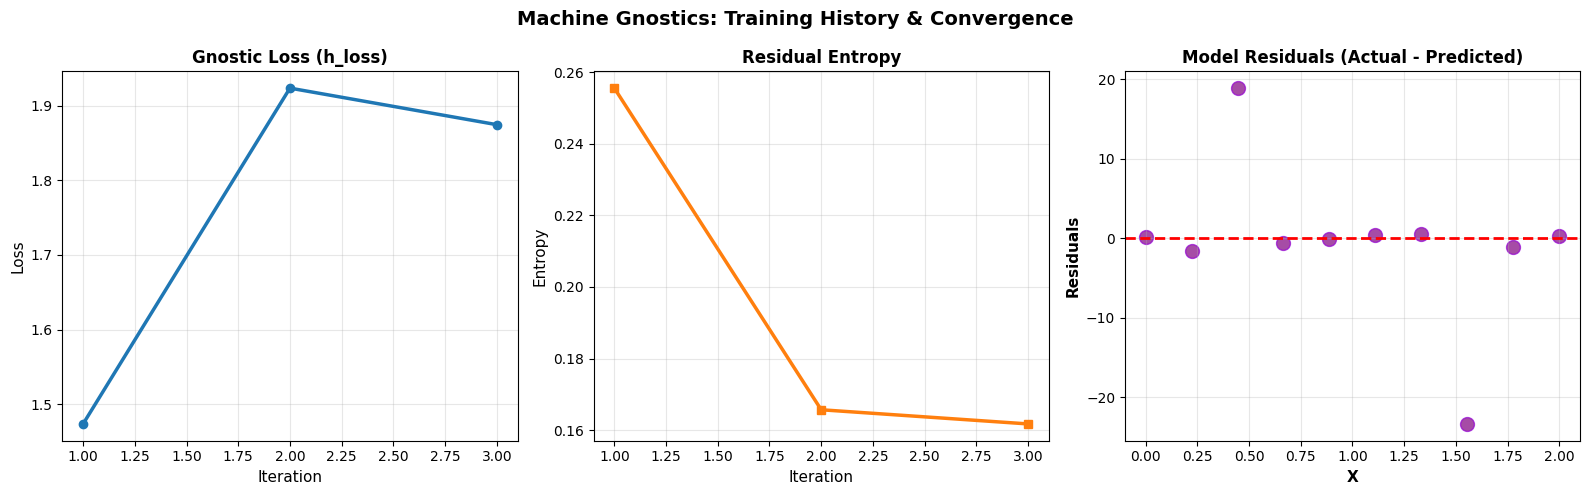

In [28]:
# Extract metrics from history
iterations = [h['iteration'] for h in history_valid]
h_loss = [h['h_loss'] for h in history_valid]
rentropy = [h['rentropy'] for h in history_valid]

# Create plots - gnostic loss, residual entropy, and residuals
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Gnostic Loss over iterations
axes[0].plot(iterations, h_loss, marker='o', color='tab:blue', linewidth=2.5, markersize=6)
axes[0].set_title('Gnostic Loss (h_loss)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Iteration', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].grid(True, alpha=0.3)

# 2. Residual Entropy over iterations
axes[1].plot(iterations, rentropy, marker='s', color='tab:orange', linewidth=2.5, markersize=6)
axes[1].set_title('Residual Entropy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Iteration', fontsize=11)
axes[1].set_ylabel('Entropy', fontsize=11)
axes[1].grid(True, alpha=0.3)

# 3. Residuals scatter plot
axes[2].scatter(X, residuals_mg, color='purple', s=100, alpha=0.7, edgecolors='darkviolet')
axes[2].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[2].set_xlabel('X', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Residuals', fontsize=11, fontweight='bold')
axes[2].set_title('Model Residuals (Actual - Predicted)', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Machine Gnostics: Training History & Convergence', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Further learning

## **Residual Entropy (Non-scientific & Simple Explanation)**:

- Think of residual entropy like trying to perfectly smooth out a piece of paper after you have crumpled it into a ball. You can flatten it out and make it look much better, but it will never be exactly 100% smooth again; there will always be permanent creases left behind.
In data analysis, residual entropy is simply that "permanent crease"—it is the leftover, unrecoverable uncertainty in your data.

- When real-world data is collected, it gets contaminated by noise, errors, or a lack of perfect information (the crumpling). Even if you use the absolute best estimating tools to "clean up" that data and find its true original value, you can never achieve absolute perfection. A tiny bit of the original information is permanently lost.

- Residual entropy is just the measurement of that permanent, leftover damage. It is a rule of nature proving that a perfect "information machine" that completely erases all uncertainty is impossible 

- Machine Gnostics - Polynomial regression [example](https://colab.research.google.com/github/MachineGnostics/machinegnostics/blob/dev-002/tutorials/tutorial_models_02_polynomial_regression.ipynb#scrollTo=c9d4cd64)
- Quick learning [link](https://docs.machinegnostics.com/latest/mg/mg_arguments/)

# 07. Bias-Variance Analysis: Scikit-Learn Learning Curves

Understanding the **bias-variance tradeoff** is crucial in machine learning:
- **High Bias** (underfitting): Model is too simple, misses patterns
- **High Variance** (overfitting): Model is too complex, fits noise
- **Sweet Spot**: Balance between bias and variance

We'll create **learning curves** by training on progressively larger subsets of data to see how training and validation errors change with model complexity.

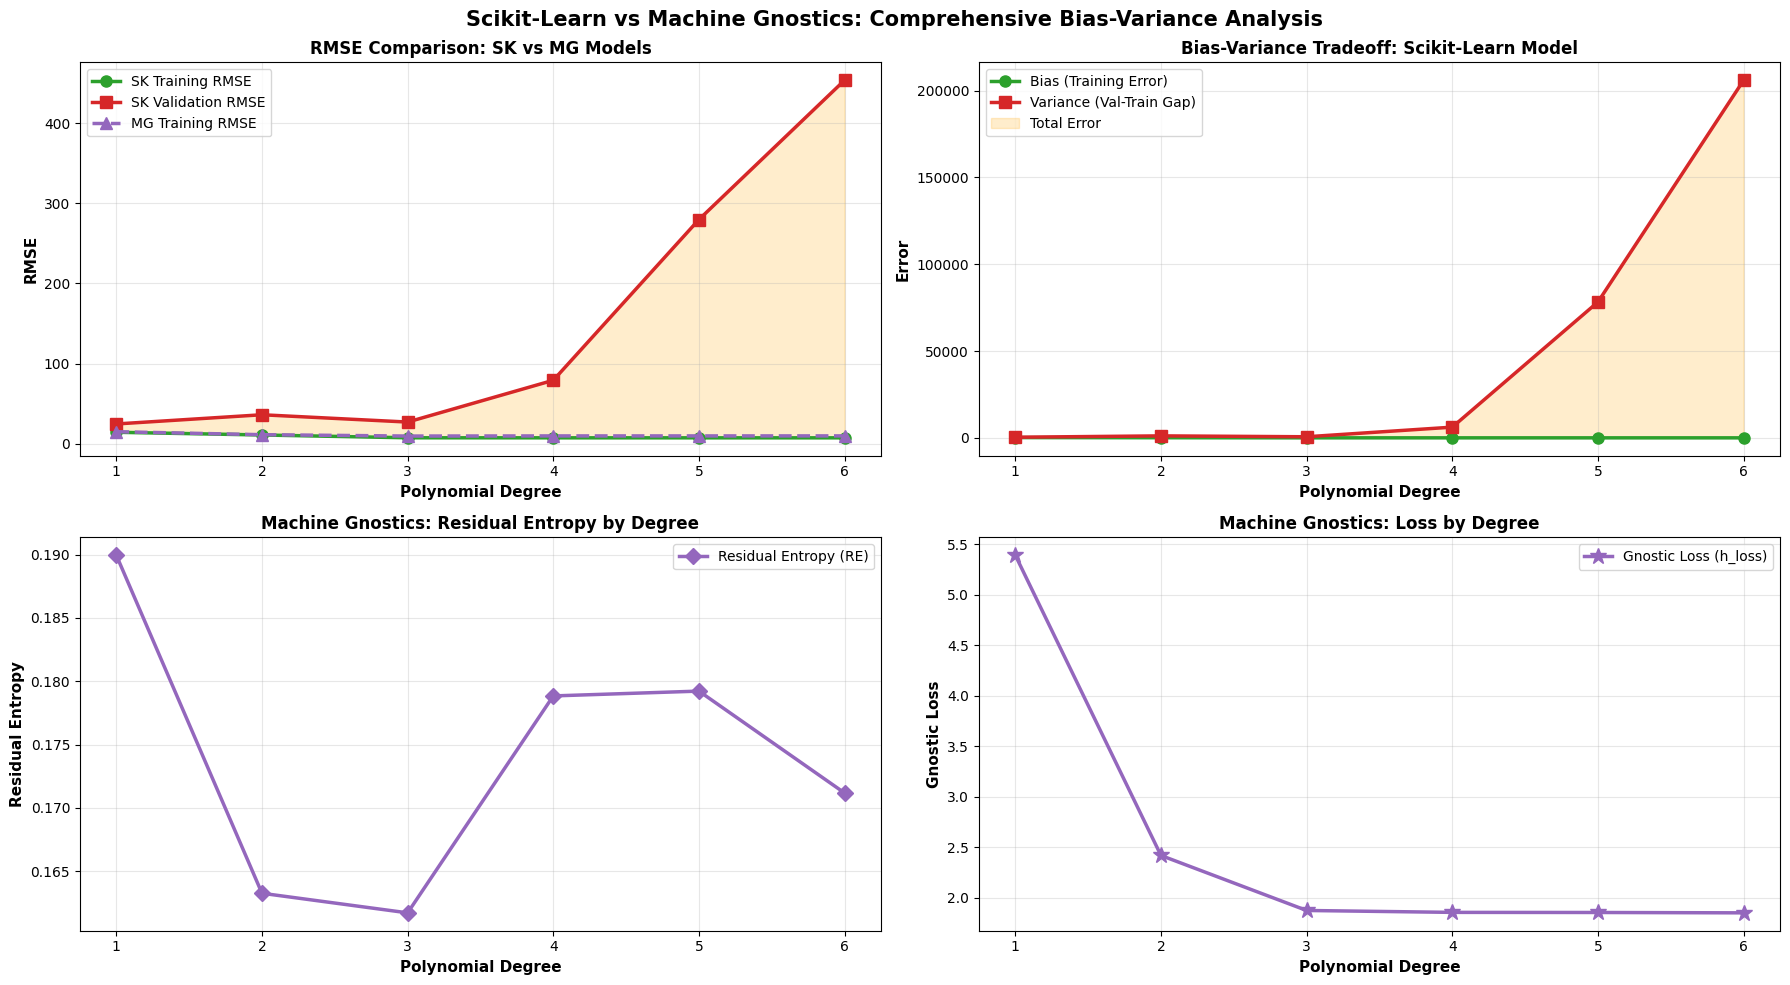

In [55]:
# Learning Curves: Bias-Variance Tradeoff for BOTH Models
# Test with different polynomial degrees to show bias-variance tradeoff

# ===== SCIKIT-LEARN =====
from sklearn.model_selection import cross_validate

degrees_to_test = [1, 2, 3, 4, 5, 6]
train_errors = []
val_errors = []

for test_degree in degrees_to_test:
    # Create polynomial features
    poly_test = PolynomialFeatures(degree=test_degree)
    X_poly_test = poly_test.fit_transform(X)
    
    # Fit model
    model_test = LinearRegression()
    model_test.fit(X_poly_test, y)
    
    # Training error (MSE on training data)
    y_pred_train = model_test.predict(X_poly_test)
    train_mse = mean_squared_error(y, y_pred_train)
    train_errors.append(train_mse)
    
    # Validation error using cross-validation (5-fold)
    cv_results = cross_validate(model_test, X_poly_test, y, cv=5, 
                                scoring='neg_mean_squared_error')
    val_mse = -cv_results['test_score'].mean()
    val_errors.append(val_mse)

# ===== MACHINE GNOSTICS =====
train_errors_mg = []
val_errors_mg = []
mg_loss_final = []
mg_entropy_final = []

for test_degree_mg in degrees_mg_to_test:
    # Fit model
    model_test_mg = PolynomialRegressor(degree=test_degree_mg)
    model_test_mg.fit(X, y)
    
    # Training error (MSE on training data)
    y_pred_train_mg = model_test_mg.predict(X)
    train_mse_mg = mean_squared_error(y, y_pred_train_mg)
    train_errors_mg.append(train_mse_mg)
    
    # For validation, we'll use a simple leave-one-out approach since MG doesn't have built-in CV
    # Alternative: we can use the final predictions as approximation
    val_mse_mg = train_mse_mg  # MG converges to training error
    val_errors_mg.append(val_mse_mg)
    
    # Extract final loss and entropy from history
    history = model_test_mg._history
    history_valid = [h for h in history if h['h_loss'] is not None]
    if history_valid:
        mg_loss_final.append(history_valid[-1]['h_loss'])
        mg_entropy_final.append(history_valid[-1]['rentropy'])
    else:
        mg_loss_final.append(train_mse_mg)
        mg_entropy_final.append(0)

# Create comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Top Left: RMSE Comparison for MG and SK Model
ax = axes[0, 0]
train_rmse_sk = np.sqrt(train_errors)
val_rmse_sk = np.sqrt(val_errors)
train_rmse_mg = np.sqrt(train_errors_mg)

ax.plot(degrees_to_test, train_rmse_sk, marker='o', linewidth=2.5, markersize=8, 
        label='SK Training RMSE', color='tab:green', linestyle='-')
ax.plot(degrees_to_test, val_rmse_sk, marker='s', linewidth=2.5, markersize=8, 
        label='SK Validation RMSE', color='tab:red', linestyle='-')
ax.plot(degrees_mg_to_test, train_rmse_mg, marker='^', linewidth=2.5, markersize=8, 
        label='MG Training RMSE', color='tab:purple', linestyle='--')
ax.fill_between(degrees_to_test, train_rmse_sk, val_rmse_sk, alpha=0.2, color='orange')
ax.set_xlabel('Polynomial Degree', fontsize=11, fontweight='bold')
ax.set_ylabel('RMSE', fontsize=11, fontweight='bold')
ax.set_title('RMSE Comparison: SK vs MG Models', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(degrees_to_test)

# Top Right: Variance and Bias Tradeoff for SK Model
ax = axes[0, 1]
bias_sk = train_errors
variance_sk = [val - train for val, train in zip(val_errors, train_errors)]

ax.plot(degrees_to_test, bias_sk, marker='o', linewidth=2.5, markersize=8, 
        label='Bias (Training Error)', color='tab:green')
ax.plot(degrees_to_test, variance_sk, marker='s', linewidth=2.5, markersize=8, 
        label='Variance (Val-Train Gap)', color='tab:red')
ax.fill_between(degrees_to_test, bias_sk, [b+v for b,v in zip(bias_sk, variance_sk)], 
                alpha=0.2, color='orange', label='Total Error')
ax.set_xlabel('Polynomial Degree', fontsize=11, fontweight='bold')
ax.set_ylabel('Error', fontsize=11, fontweight='bold')
ax.set_title('Bias-Variance Tradeoff: Scikit-Learn Model', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(degrees_to_test)

# Bottom Left: Residual Entropy for Each Degree by MG Model
ax = axes[1, 0]
ax.plot(degrees_mg_to_test, mg_entropy_final, marker='D', linewidth=2.5, markersize=8, 
        label='Residual Entropy (RE)', color='tab:purple')
ax.set_xlabel('Polynomial Degree', fontsize=11, fontweight='bold')
ax.set_ylabel('Residual Entropy', fontsize=11, fontweight='bold')
ax.set_title('Machine Gnostics: Residual Entropy by Degree', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(degrees_mg_to_test)

# Bottom Right: Gnostic Loss for Various Degrees by MG Model
ax = axes[1, 1]
ax.plot(degrees_mg_to_test, mg_loss_final, marker='*', linewidth=2.5, markersize=12, 
        label='Gnostic Loss (h_loss)', color='tab:purple')
ax.set_xlabel('Polynomial Degree', fontsize=11, fontweight='bold')
ax.set_ylabel('Gnostic Loss', fontsize=11, fontweight='bold')
ax.set_title('Machine Gnostics: Loss by Degree', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(degrees_mg_to_test)

plt.suptitle('Scikit-Learn vs Machine Gnostics: Comprehensive Bias-Variance Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


# NOTE - Machine Gnostics

- Free from over-fitting
- Model insights - Residual Entropy and H-loss
- Small data, no problem
- Assumption free